In [1]:
import pandas as pd
import calendar
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from RNNs_utils import *
from RNNs_model import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
weekly = pd.read_csv('../Datasets/paper_data/Boulder_Weekly.csv')
weekly['Month'] = weekly['Month_num'].apply(lambda x: calendar.month_name[x])
weekly.drop(columns={'Unnamed: 0','Date', 'Week_num', 'Month_num', 'Year'}, inplace=True)
weekly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Energy__kWh_   286 non-null    float64
 1   Minimum T      286 non-null    float64
 2   Maximum T      286 non-null    float64
 3   Snow           286 non-null    float64
 4   Precipitation  286 non-null    float64
 5   Month          286 non-null    object 
dtypes: float64(5), object(1)
memory usage: 13.5+ KB


## **Preprocessing**

In [3]:
train_weekly, val_weekly, test_weekly = split_dataset(weekly, train_ratio=0.7, val_ratio=0.2)

Training split ratio:   0.699
Validation split ratio: 0.199
Testing split ratio:    0.101

Shapes of the datasets:
(200, 6) (57, 6) (29, 6)


    One Hot Encode

In [4]:
# One-hot encode 'Month' column for train_weekly and drop 'Month' column after one-hot encoding
train_weekly = one_hot_months(train_weekly)
train_weekly.drop(columns=['Month'], inplace=True)

# One-hot encode 'Month' column for val_weekly and drop 'Month' column after one-hot encoding
val_weekly = one_hot_months(val_weekly)
val_weekly.drop(columns=['Month'], inplace=True)

# One-hot encode 'Month' column for test_weekly and drop 'Month' column after one-hot encoding
test_weekly = one_hot_months(test_weekly)
test_weekly.drop(columns=['Month'], inplace=True)

In [5]:
train_weekly.head(15)

,Energy__kWh_,Minimum T,Maximum T,Snow,Precipitation,January,February,March,April,May,June,July,August,September,October,November,December
0,6.303917,24.583333,53.666667,0.000000,0.000000,1,0,0,0,0,0,0,0,0,0,0,0
1,7.051590,29.743590,54.102564,0.000000,0.052103,1,0,0,0,0,0,0,0,0,0,0,0
2,7.220676,21.864865,55.486486,10.915135,0.961081,1,0,0,0,0,0,0,0,0,0,0,0
3,6.326153,22.444444,48.916667,0.000000,0.000000,1,0,0,0,0,0,0,0,0,0,0,0
4,5.125958,27.375000,60.666667,0.000000,0.000000,1,0,0,0,0,0,0,0,0,0,0,0
5,8.484216,24.054054,50.216216,3.707027,0.226541,0,1,0,0,0,0,0,0,0,0,0,0
6,7.273791,23.238806,52.268657,12.351982,0.704452,0,1,0,0,0,0,0,0,0,0,0,0
7,8.348973,25.067568,51.891892,3.016765,0.225785,0,1,0,0,0,0,0,0,0,0,0,0
8,8.435941,8.376471,32.176471,28.622812,1.565387,0,1,0,0,0,0,0,0,0,0,0,0
9,6.800065,23.258065,50.322581,0.000000,0.000000,0,1,0,0,0,0,0,0,0,0,0,0


    Create sequences for the RNNs model

In [6]:
# Define the time window size
sequence_length = 22

# Create sequences for training data
X_train, Y_train = create_sequences(train_weekly, sequence_length, 'Energy__kWh_', step=1)
# Create sequences for validation data
X_val, Y_val = create_sequences(val_weekly, sequence_length, 'Energy__kWh_', step=1)
# Create sequences for test data
X_test, Y_test = create_sequences(test_weekly, sequence_length, 'Energy__kWh_', step=1)

Dataset split into sequences:
Sequences shape: (178, 22, 17)
Targets shape: (178,)

Dataset split into sequences:
Sequences shape: (35, 22, 17)
Targets shape: (35,)

Dataset split into sequences:
Sequences shape: (7, 22, 17)
Targets shape: (7,)



**Scalling the Numerical columns**

    Scaling the X_train and Y_train

In [7]:
# We scale also with MinMaxScaler this input columns ['Energy__kWh_', 'Maximum T', 'Minimum T', 'Precipitation', 'Snow']
numerical_D = len(['Energy__kWh_', 'Maximum T', 'Minimum T', 'Precipitation', 'Snow'])

# ----------------------
#    SCALE THE X_train
# ----------------------

# Initialize the input scaler
inputs_scaler = MinMaxScaler()
# Extract the first 5 columns from X_train
X_train_subset = X_train[:, :, :numerical_D]
# Reshape the subset to 2D array
X_train_subset_2d = X_train_subset.reshape(-1, numerical_D)
# Fit the scaler on the subset and transform it. Also reshape the scaled subset back to the original shape
x_scaler = inputs_scaler.fit_transform(X_train_subset_2d).reshape(X_train.shape[0], X_train.shape[1], numerical_D)
# Combine the scaled subset with the remaining columns of X_train
X_train_scaled = np.concatenate([x_scaler, X_train[:, :, numerical_D:]], axis=-1)

# ----------------------
#    SCALE THE Y_train
# ----------------------

# Initialize the output scaler
output_scaler = MinMaxScaler()
# Reshape the subset to 2D array
Y_train_reshaped = Y_train.reshape(-1,1)
Y_train_scaled = output_scaler.fit_transform(Y_train_reshaped)

    Scaling the X_val, X_test and Y_val, Y_test accord to X_train MinMaxScaler

In [8]:
def scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X, Y, numerical_D):
    # ----------------------
    #    SCALE THE X_array with the fitted scaler of X_train
    # ----------------------
    # Extract the first 5 columns from X
    X_subset = X[:, :, :numerical_D].reshape(-1, numerical_D)
    # Scaling 
    X_scaled_subset = inputs_scaler.transform(X_subset).reshape(X.shape[0], X.shape[1], numerical_D)
    # Combine the scaled subset with the remaining columns of X
    X_scaled = np.concatenate([X_scaled_subset, X[:, :, numerical_D:]], axis=-1)

    # ----------------------
    #    SCALE THE Y_array with the fitted scaler of X_train
    # ----------------------

    # Reshape the subset of Y to 2D array
    Y_reshaped = Y.reshape(-1,1)
    # Use the previously fitted scaler to transform the Y_reshaped
    Y_scaled = output_scaler.transform(Y_reshaped)

    return X_scaled, Y_scaled

X_val_scaled, Y_val_scaled = scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X_val, Y_val, numerical_D)
X_test_scaled, Y_test_scaled = scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X_test, Y_test, numerical_D)

print('Train Dataset:')
print("scaled X_train shape:", X_train_scaled.shape)
print("scaled Y_train shape:", Y_train_scaled.shape)

print('\nValidation Dataset:')
print("scaled X_val shape:", X_val_scaled.shape)
print("scaled Y_val shape:", Y_val_scaled.shape)

print('\nTest Dataset:')
print("scaled X_test shape:", X_test_scaled.shape)
print("scaled Y_test shape:", Y_test_scaled.shape)

Train Dataset:
scaled X_train shape: (178, 22, 17)
scaled Y_train shape: (178, 1)

Validation Dataset:
scaled X_val shape: (35, 22, 17)
scaled Y_val shape: (35, 1)

Test Dataset:
scaled X_test shape: (7, 22, 17)
scaled Y_test shape: (7, 1)


In [9]:
X_train_scaled.max(), X_val_scaled.max(), X_test_scaled.max()

(1.0, 1.262568237864151, 1.029273891279921)

In [10]:
X_train_scaled.min(), X_val_scaled.min(), X_test_scaled.min()

(0.0, -0.09893647359098245, 0.0)

    Create the RNNs Models

In [11]:
# Define the input shape for the models ||  input_shape = (sequence_length, num_features)
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

# Define common parameters
simple_rnn_num_layers, lstm_num_layers, bi_lstm_num_layers, gru_num_layers = 3, 3, 3, 3
simple_rnn_num_units, lstm_num_units, bi_lstm_num_units, gru_num_units = 128, 128, 64, 63
recurrent_activation_function = 'relu'
# Define the default regularation l2=0.01  ||  If we want we can train the model without regularations. (regularization = 0)
kernel_regularization = 0.01
recurrent_regularization = 0
bias_regularization = 0
dropout_rate = 0
recurrent_dropout_rate = 0.1

In [12]:
# -------------------
# Build the Models
# -------------------

# Create Simple RNN model
simple_rnn = RnnModel('SimpleRNN', input_shape, simple_rnn_num_layers, simple_rnn_num_units, recurrent_activation_function,
                      recurrent_regularization, kernel_regularization, bias_regularization,
                      dropout_rate, recurrent_dropout_rate)

# Create LSTM model
lstm = RnnModel('LSTM', input_shape, lstm_num_layers, lstm_num_units, recurrent_activation_function,
                recurrent_regularization, kernel_regularization, bias_regularization,
                dropout_rate, recurrent_dropout_rate)

# Create GRU model
gru = RnnModel('GRU', input_shape, gru_num_layers, gru_num_units, recurrent_activation_function,
               recurrent_regularization, kernel_regularization, bias_regularization,
               dropout_rate, recurrent_dropout_rate)

# Create Bi-LSTM model
bi_lstm = RnnModel('Bi-LSTM', input_shape, bi_lstm_num_layers, bi_lstm_num_units, recurrent_activation_function,
                   recurrent_regularization, kernel_regularization, bias_regularization,
                   dropout_rate, recurrent_dropout_rate)


print("Models created successfully.")

Models created successfully.


In [13]:
# Print summaries of the configurations
print("LSTM Summary:")
lstm.summary()
print()

print("Simple RNN Summary:")
simple_rnn.summary()
print()

print("Bi-LSTM Summary:")
bi_lstm.summary()
print()

print("GRU Summary:")
gru.summary()

LSTM Summary:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 22, 128)           74752     
                                                                 
 lstm_1 (LSTM)               (None, 22, 128)           131584    
                                                                 
 lstm_2 (LSTM)               (None, 128)               131584    
                                                                 
 dense_1 (Dense)             (None, 1)                 129       
                                                                 
Total params: 338,049
Trainable params: 338,049
Non-trainable params: 0
_________________________________________________________________

Simple RNN Summary:
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Para

    Compile the models

In [14]:
# Define the learning rate for Adam optimizer
learning_rate = 0.001

# Define a dictionary to map model names to their corresponding model objects
rnn_models = {
    'simple_rnn': simple_rnn,
    'lstm': lstm,
    'gru': gru,
    'bi_lstm': bi_lstm
}

# Compile each RNN model
for model_name, model in rnn_models.items():
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = learning_rate), loss='mse', metrics=['mae', root_mean_squared_error])

    Train the Models

In [15]:
def train_rnn_model(model, X_train, Y_train, X_val, Y_val, epochs, batch_size, model_name):
    """
    Train an RNN model and save it.
    
    Args:
    - model: The RNN model to train.
    - X_train: Input data for training.
    - Y_train: Target data for training.
    - X_val: Input data for validation.
    - Y_val: Target data for validation.
    - epochs: Number of epochs for training.
    - batch_size: Batch size for training.
    - model_name: The name of the model to save.
    
    Returns:
    - History object containing training/validation loss and metric values.
    """
    history = model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, Y_val)
    )
    
    # Save the trained model
    model.save(f"{model_name}.h5")  # Save as HDF5 file
    print(f"Model saved as {model_name}.h5")
    
    return history

In [16]:
# Define the parameters for training
lstm_epochs = 50
simple_rnn_epochs = 100
bi_lstm_epochs, gru_epochs = 200, 200
batch_size = 1

# Train each RNN model and save them
print('-----------------\nLSTM Training\n-----------------\n')
lstm_history = train_rnn_model(lstm, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, lstm_epochs, batch_size, "weekly_lstm_model")

print('\n-----------------\nSimpleRNN / Vanilla RNN Training\n-----------------\n')
simple_rnn_history = train_rnn_model(simple_rnn, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, simple_rnn_epochs, batch_size, "weekly_simple_rnn_model")

print('\n-----------------\nBi-LSTM Training\n-----------------\n')
bi_lstm_history = train_rnn_model(bi_lstm, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, bi_lstm_epochs, batch_size, "weekly_bi_lstm_model")

print('\n-----------------\nGRU Training\n-----------------\n')
gru_history = train_rnn_model(gru, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, gru_epochs, batch_size, "weekly_gru_model")

-----------------
LSTM Training
-----------------

Epoch 1/50
178/178 [==============================] - 24s 73ms/step - loss: 0.7941 - mae: 0.1573 - root_mean_squared_error: 0.1573 - val_loss: 0.0689 - val_mae: 0.1476 - val_root_mean_squared_error: 0.1476
Epoch 2/50
178/178 [==============================] - 10s 59ms/step - loss: 0.0439 - mae: 0.1226 - root_mean_squared_error: 0.1226 - val_loss: 0.0703 - val_mae: 0.2058 - val_root_mean_squared_error: 0.2058
Epoch 3/50
178/178 [==============================] - 10s 58ms/step - loss: 0.0337 - mae: 0.1278 - root_mean_squared_error: 0.1278 - val_loss: 0.0396 - val_mae: 0.1443 - val_root_mean_squared_error: 0.1443
Epoch 4/50
178/178 [==============================] - 11s 62ms/step - loss: 0.0310 - mae: 0.1316 - root_mean_squared_error: 0.1316 - val_loss: 0.0424 - val_mae: 0.1558 - val_root_mean_squared_error: 0.1558
Epoch 5/50
178/178 [==============================] - 10s 56ms/step - loss: 0.0276 - mae: 0.1269 - root_mean_squared_error: 0

    Evaluate the Models

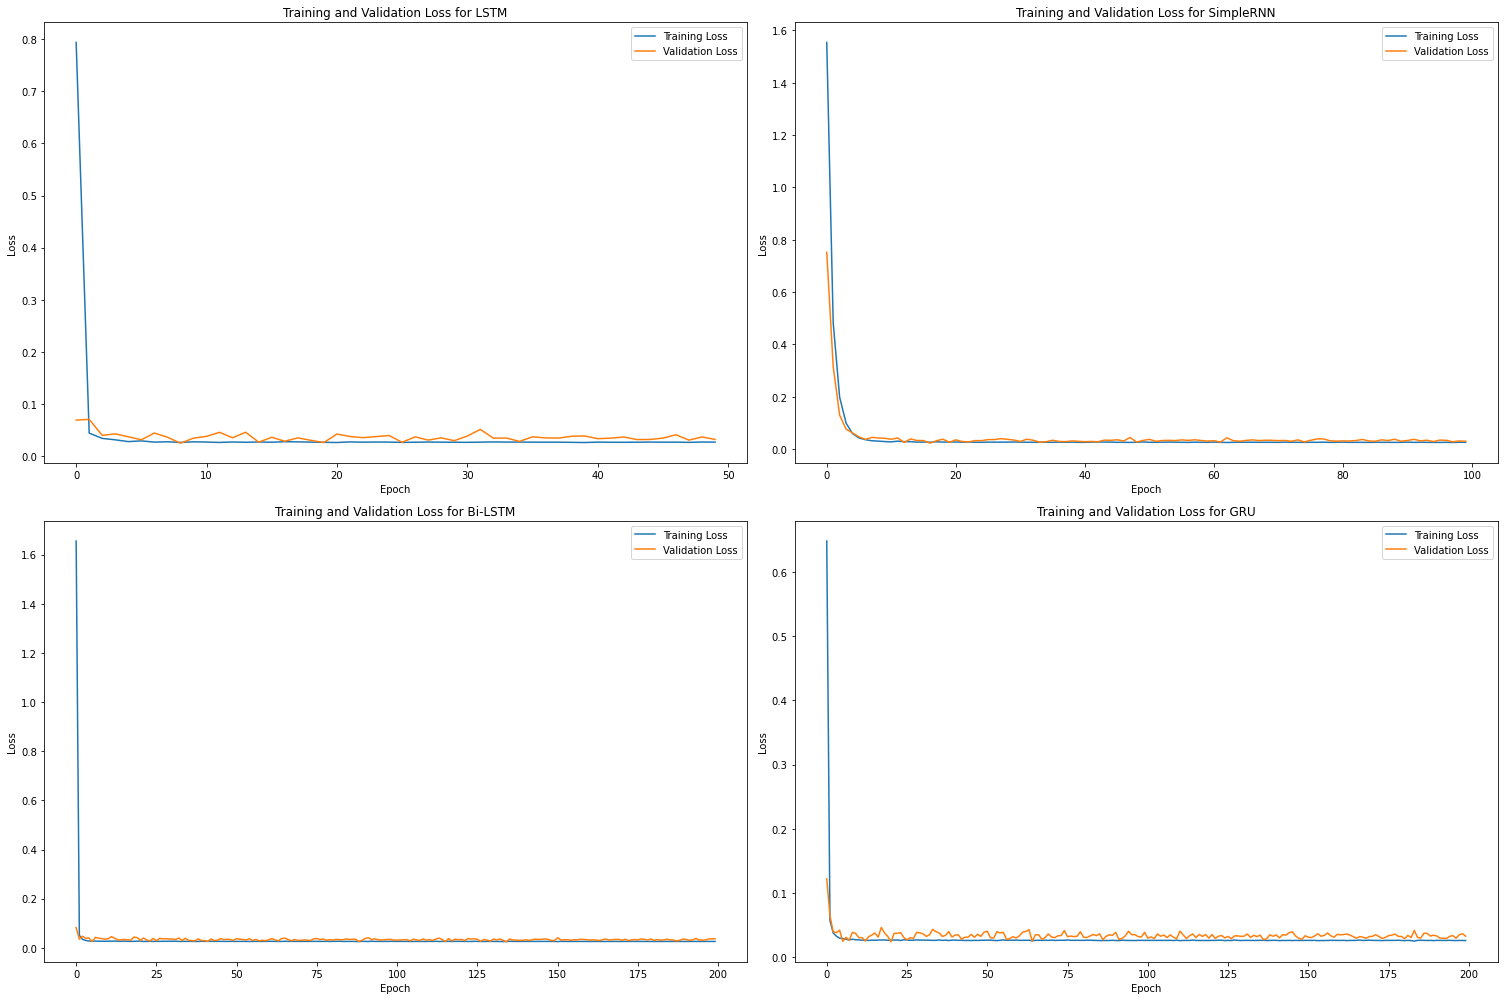

In [17]:
def plot_loss(history, model_name, ax):
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training and Validation Loss for ' + model_name)
    ax.legend()

    

fig, axes = plt.subplots(2, 2, figsize=(21, 14))
axes = axes.flatten()
histories = []
model_names = ['LSTM', 'SimpleRNN', 'Bi-LSTM', 'GRU']
histories.extend([lstm_history, simple_rnn_history, bi_lstm_history, gru_history])
for i, (history, model_name) in enumerate(zip(histories, model_names)):
    plot_loss(history, model_name, axes[i])
# Hide empty subplots
for i in range(len(histories), len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [11]:
# from tensorflow.keras.models import load_model

# # Load each model, passing the custom RMSE function
# lstm = load_model('../model_saves/paper_method/weekly_lstm_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# simple_rnn = load_model('../model_saves/paper_method/weekly_simple_rnn_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# bi_lstm = load_model('../model_saves/paper_method/weekly_bi_lstm_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# gru = load_model('../model_saves/paper_method/weekly_gru_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})

In [12]:
##     Evaluate the Models in scaled data
def evaluate_model(model, model_name, X_train, Y_train, X_val, Y_val, X_test, Y_test):
    train_eval = model.evaluate(X_train, Y_train, verbose=0)
    val_eval = model.evaluate(X_val, Y_val, verbose=0)
    test_eval = model.evaluate(X_test, Y_test, verbose=0)
    print(f'\nEvaluation metrics for {model_name} model:\n-------------------')
    print('Training Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(train_eval[0], train_eval[1], train_eval[2]))
    print('Validation Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(val_eval[0], val_eval[1], val_eval[2]))
    print('Test Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(test_eval[0], test_eval[1], test_eval[2]),'\n')
    # print(model.metrics_names)

##     Evaluate the Models in scaled data
evaluate_model(lstm, 'LSTM',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(simple_rnn, 'RNN',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(bi_lstm, 'Bi-LSTM',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(gru, 'GRU',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)


Evaluation metrics for LSTM model:
-------------------
Training Data - Loss: 0.0257, MAE: 0.1216, RMSE: 0.1538
Validation Data - Loss: 0.0317, MAE: 0.1349, RMSE: 0.2022
Test Data - Loss: 0.0083, MAE: 0.0734, RMSE: 0.0909 


Evaluation metrics for RNN model:
-------------------
Training Data - Loss: 0.0259, MAE: 0.1219, RMSE: 0.1540
Validation Data - Loss: 0.0303, MAE: 0.1320, RMSE: 0.1970
Test Data - Loss: 0.0072, MAE: 0.0679, RMSE: 0.0851 


Evaluation metrics for Bi-LSTM model:
-------------------
Training Data - Loss: 0.0261, MAE: 0.1231, RMSE: 0.1555
Validation Data - Loss: 0.0371, MAE: 0.1464, RMSE: 0.2196
Test Data - Loss: 0.0123, MAE: 0.0947, RMSE: 0.1111 


Evaluation metrics for GRU model:
-------------------
Training Data - Loss: 0.0257, MAE: 0.1217, RMSE: 0.1538
Validation Data - Loss: 0.0329, MAE: 0.1373, RMSE: 0.2061
Test Data - Loss: 0.0091, MAE: 0.0776, RMSE: 0.0955 



In [13]:
evaluate_predictions_model(lstm, 'LSTM', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(simple_rnn, 'RNN', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(bi_lstm, 'Bi-LSTM', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(gru, 'GRU', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)

1/1 [==============================] - 0s 93ms/step


Evaluation metrics for LSTM model:
-------------------
Train RMSE: 1.20 // 0.16044307710082822
Train MAE: 0.91 // 0.12163792755461277
-------------------
Validation RMSE: 1.33 // 0.17810136709130903
Validation MAE: 1.01 // 0.13489710137066938
-------------------
Test RMSE: 0.68 // 0.09092561749436386
Test MAE: 0.55 // 0.07341397374878987


1/1 [==============================] - 0s 60ms/step


Evaluation metrics for RNN model:
-------------------
Train RMSE: 1.20 // 0.16089705640865598
Train MAE: 0.91 // 0.1219017650508022
-------------------
Validation RMSE: 1.30 // 0.1740067291148079
Validation MAE: 0.99 // 0.13200988303156677
-------------------
Test RMSE: 0.64 // 0.0850903949344456
Test MAE: 0.51 // 0.06786163078897715


1/1 [==============================] - 0s 65ms/step


Evaluation metrics for Bi-LSTM model:
-------------------
Train RMSE: 1.21 // 0.16150021470466103
Train MAE: 0.92 // 0.12312788185292506
-------------------
V